In [1]:
print("hello")

hello


In [68]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from wordcloud import wordcloud
import warnings
warnings.filterwarnings("ignore")


In [40]:
df = pd.read_csv(
    "data4.csv",
    header = None,
    names = ["Tweet_ID","Entity","Sentiment","Tweet"]
)

df.head()

,Tweet_ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Tweet_ID   74682 non-null  int64
 1   Entity     74682 non-null  str  
 2   Sentiment  74682 non-null  str  
 3   Tweet      73996 non-null  str  
dtypes: int64(1), str(3)
memory usage: 2.3 MB


In [42]:
df.isnull().sum()

Tweet_ID       0
Entity         0
Sentiment      0
Tweet        686
dtype: int64

In [ ]:
df.shape

(74682, 4)

In [46]:
df.drop_duplicates(inplace=True)

In [47]:
df.shape

(71982, 4)

In [49]:
sentiment_count = df["Sentiment"].value_counts()
print(sentiment_count)

Sentiment
Negative      21787
Positive      19811
Neutral       17800
Irrelevant    12584
Name: count, dtype: int64


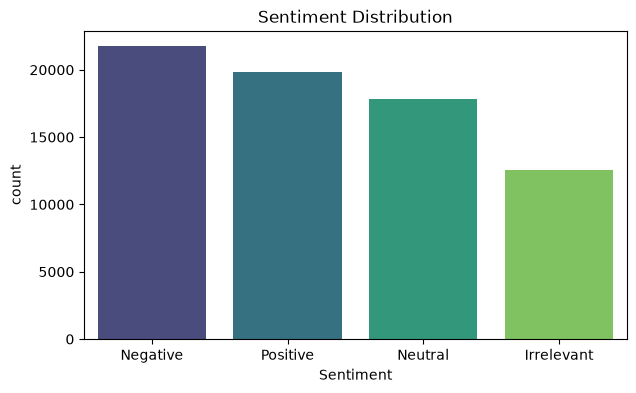

In [53]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x="Sentiment",
    order=df["Sentiment"].value_counts().index,
    palette='viridis'
)

plt.title("Sentiment Distribution")
plt.show()

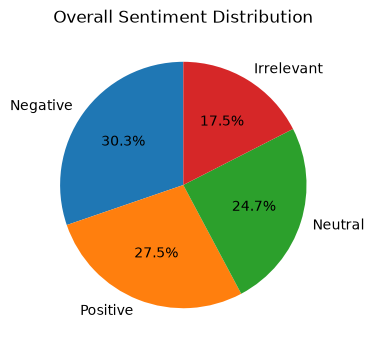

In [55]:
plt.figure(figsize=(7,4))

df["Sentiment"].value_counts().plot(
    kind='pie',
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")
plt.title("Overall Sentiment Distribution")

plt.show()

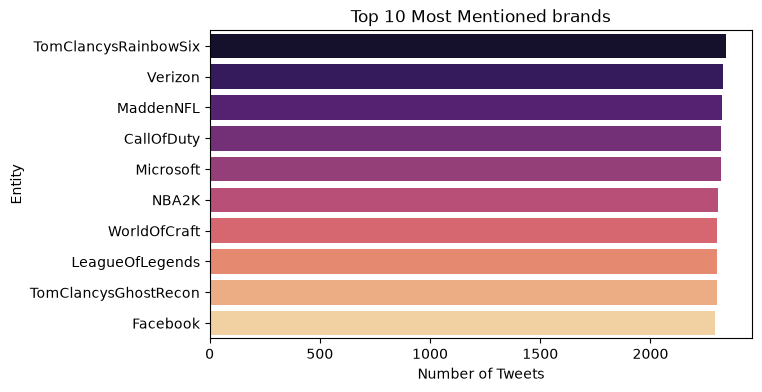

In [59]:
top_brands = df["Entity"].value_counts().head(10)

plt.figure(figsize=(7,4))

sns.barplot(
    x=top_brands.values,
    y=top_brands.index,
    palette="magma"
)

plt.title("Top 10 Most Mentioned brands")

plt.xlabel("Number of Tweets")
plt.show()

In [62]:
brand_sentiment = pd.crosstab(
    df["Entity"],
    df["Sentiment"]
)

brand_sentiment.head()

Sentiment,Irrelevant,Negative,Neutral,Positive
Entity,,,,
Amazon,187,566,1207,304
ApexLegends,185,579,915,610
AssassinsCreed,256,366,153,1385
Battlefield,908,449,345,565
Borderlands,238,415,584,974


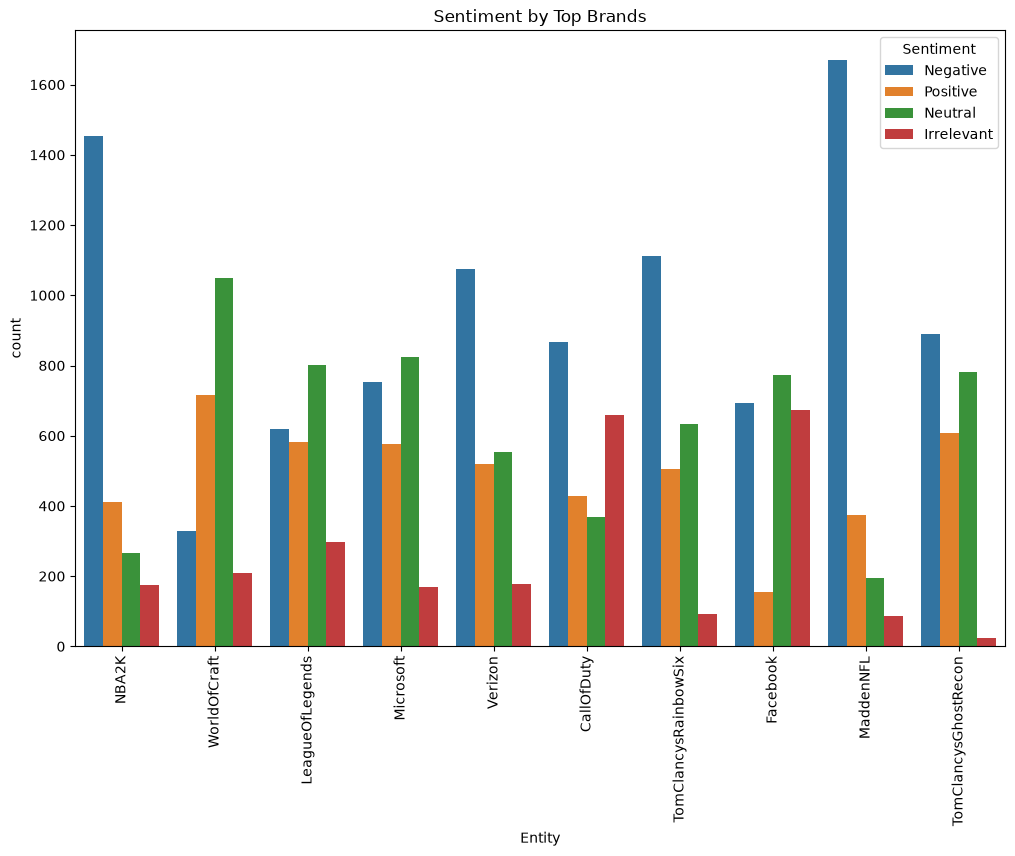

In [63]:
top = df["Entity"].value_counts().head(10).index

plt.figure(figsize=(12,8))

sns.countplot(
    data=df[df["Entity"].isin(top)],
    x="Entity",
    hue="Sentiment"
)

plt.xticks(rotation=90)

plt.title("Sentiment by Top Brands")

plt.show()

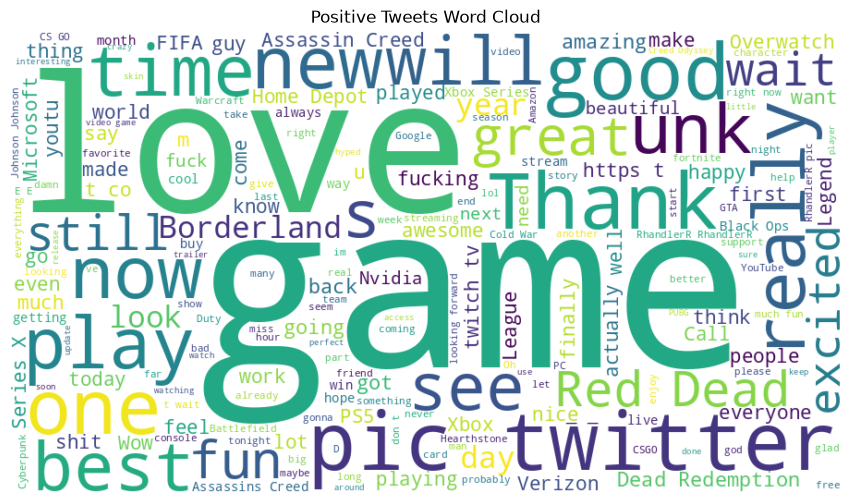

In [70]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positive = " ".join(
    df[df["Sentiment"] == "Positive"]["Tweet"].dropna().astype(str)
)

wordcloud = WordCloud(
    width=900,
    height=500,
    background_color="white"
).generate(positive)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Tweets Word Cloud")
plt.show()

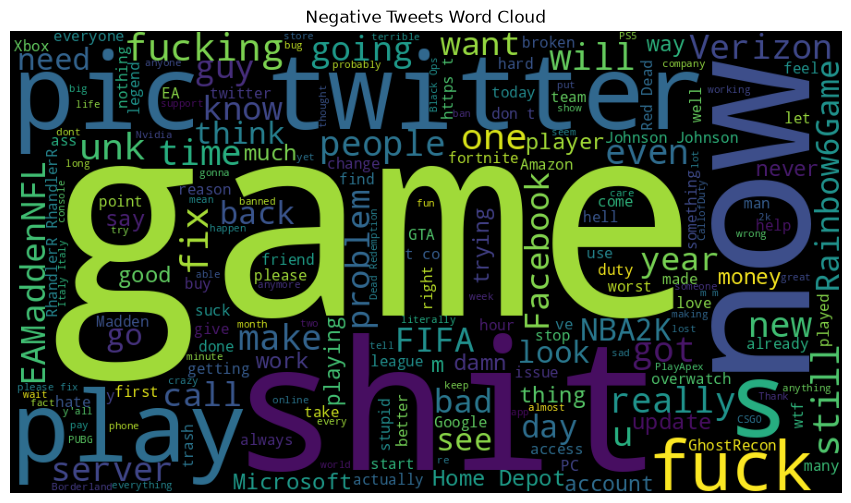

In [71]:
negative = " ".join(
    df[df["Sentiment"]=="Negative"]["Tweet"].dropna().astype(str)
)

wordcloud = WordCloud(
    width=900,
    height=500,
    background_color="black"
).generate(negative)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Negative Tweets Word Cloud")

plt.show()

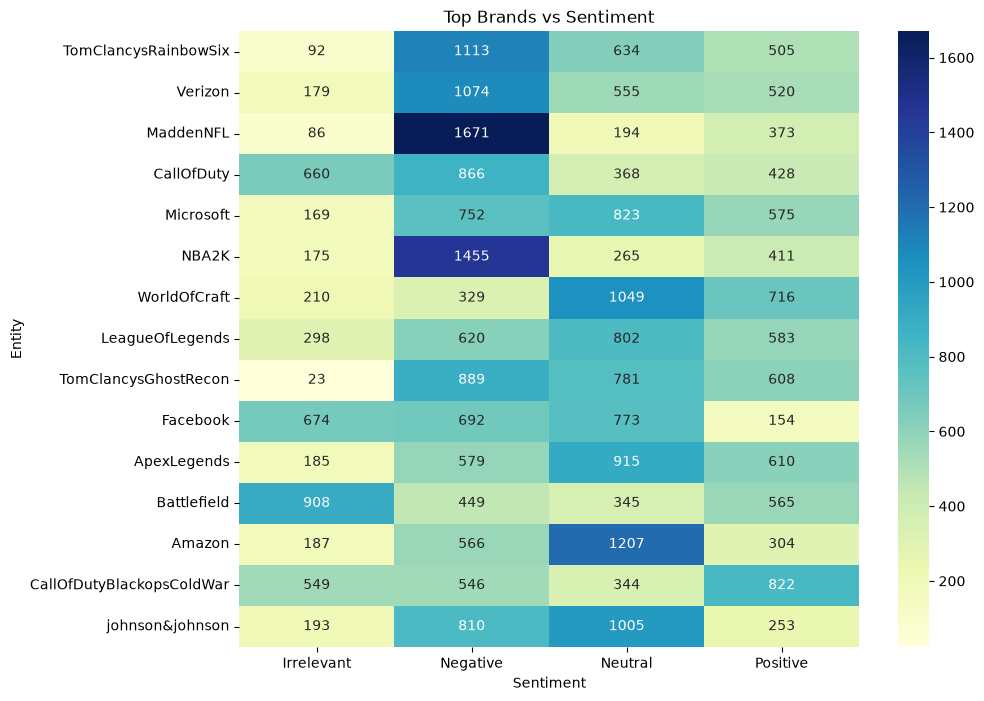

In [72]:
pivot = pd.crosstab(
    df["Entity"],
    df["Sentiment"]
)

top = pivot.sum(axis=1).sort_values(ascending=False).head(15).index

plt.figure(figsize=(10,8))

sns.heatmap(
    pivot.loc[top],
    cmap="YlGnBu",
    annot=True,
    fmt="d"
)

plt.title("Top Brands vs Sentiment")

plt.show()